**1.Upload the ZIP**

In [2]:
from google.colab import files

uploaded = files.upload()


Saving dataset.zip to dataset.zip


**2. Extract it**

In [3]:
import zipfile
import os

zip_path = "/content/dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/SmartWaste")

print("Dataset extracted successfully!")

Dataset extracted successfully!


**3.find your glass, metal, and paper folders**

In [4]:
for root, dirs, files in os.walk("/content/SmartWaste"):
    if "glass" in dirs and "metal" in dirs and "paper" in dirs:
        print("Dataset path:", root)

Dataset path: /content/SmartWaste/dataset


In [5]:
dataset_path = "/content/SmartWaste/dataset"

**4.Verify your images**

In [6]:
classes = ["glass", "metal", "paper"]

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    print(f"{cls}: {len(images)} images")

glass: 501 images
metal: 409 images
paper: 592 images


**1. Set paths and configuration**

In [7]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

dataset_path = "/content/SmartWaste/dataset"

classes = ["glass", "metal", "paper"]

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**2. Collect all image paths**

In [8]:
image_paths = []
image_labels = []

for label, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

            image_paths.append(os.path.join(folder, file))
            image_labels.append(label)

print("Total images:", len(image_paths))

Total images: 1502


**3. Split 70/15/15**

In [9]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=image_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_paths))

Training: 1051
Validation: 225
Testing: 226


**4. Create preprocessing function**

In [10]:
def load_and_preprocess(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32)

    img.set_shape([224, 224, 3])

    return img, label

**5. Create datasets**

In [11]:
def make_dataset(paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = make_dataset(
    val_paths,
    val_labels
)

test_ds = make_dataset(
    test_paths,
    test_labels
)

print("Datasets recreated successfully!")

Datasets recreated successfully!


**6. Check one batch**

In [12]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Minimum:", tf.reduce_min(images).numpy())
print("Maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Minimum: 0.0
Maximum: 255.0


**7. Data augmentation**

In [13]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.10),

    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomContrast(0.10)

], name="data_augmentation")

**8. Display augmentation**

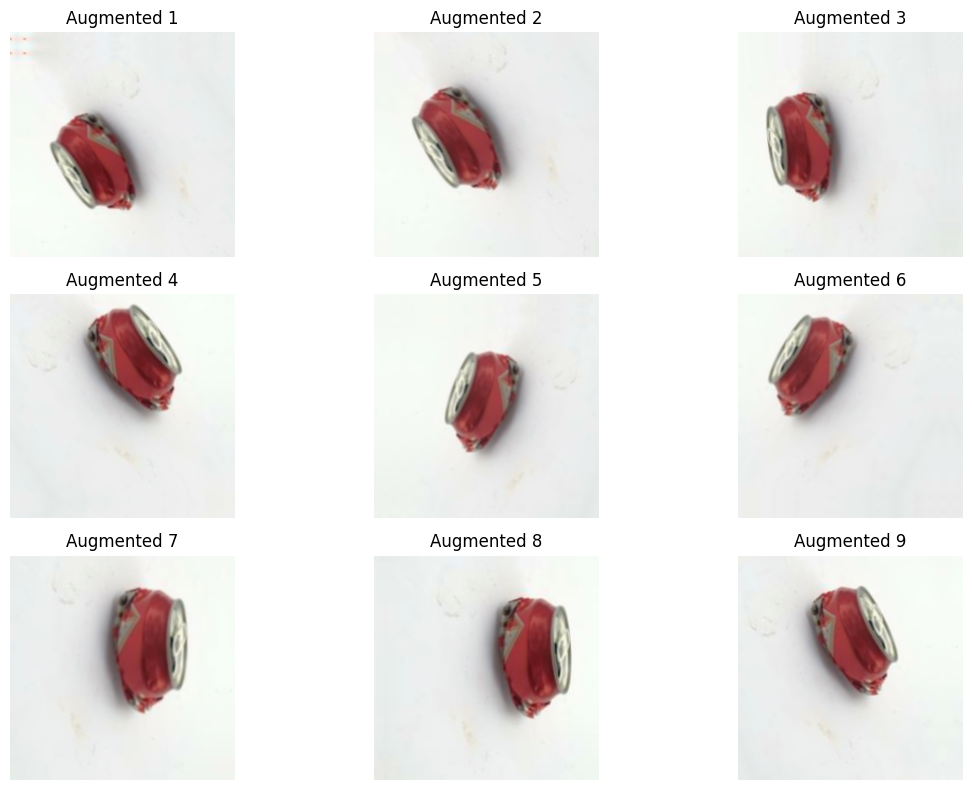

In [14]:
# Display augmented images

import matplotlib.pyplot as plt
import tensorflow as tf

# Get one image from training dataset
images, labels = next(iter(train_ds))

# Take the first image
original_image = images[0]

plt.figure(figsize=(12, 8))

for i in range(9):

    # Apply augmentation to the single image
    augmented = data_augmentation(
        tf.expand_dims(original_image, axis=0),
        training=True
    )

    # Remove batch dimension
    augmented_image = augmented[0]

    # Convert 0-255 to 0-1 for matplotlib
    augmented_image = augmented_image / 255.0

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.clip_by_value(augmented_image, 0, 1)
    )

    plt.axis("off")
    plt.title(f"Augmented {i + 1}")

plt.tight_layout()
plt.show()

**9. Build EfficientNetB0**

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**10. Build the model**

In [16]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.40)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,534 (15.48 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

**11. Compile**

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**12. Training callbacks**

In [18]:
import os

os.makedirs("/content/models", exist_ok=True)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

**13. Train Phase 1**

In [19]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5512 - loss: 1.2193
Epoch 1: val_accuracy improved from None to 0.88444, saving model to /content/models/best_model.keras

Epoch 1: finished saving model to /content/models/best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.6755 - loss: 0.8677 - val_accuracy: 0.8844 - val_loss: 0.4106 - learning_rate: 0.0010
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8255 - loss: 0.4805
Epoch 2: val_accuracy improved from 0.88444 to 0.93778, saving model to /content/models/best_model.keras

Epoch 2: finished saving model to /content/models/best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8449 - loss: 0.4277 - val_accuracy: 0.9378 - val_loss: 0.2902 - learning_rate: 0.0010
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8593 - loss: 0.3527
Epoch 3: val_accuracy improved from 0.93778 to 0.94667, saving model to /content/models/best_model.keras

Epoch 3: fini

**14. Plot training results**

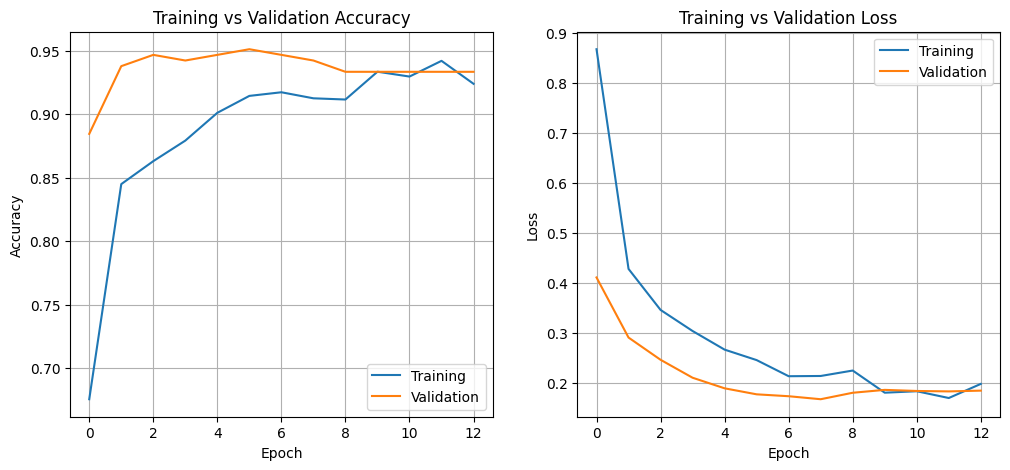

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history1.history["accuracy"])
plt.plot(history1.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.grid()

plt.subplot(1, 2, 2)

plt.plot(history1.history["loss"])
plt.plot(history1.history["val_loss"])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.grid()

plt.show()

**15. Fine-tuning**

In [21]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Trainable layers:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block6d_expand_bn
block6d_expand_activation
block6d_dwconv
block6d_bn
block6d_activation
block6d_se_squeeze
block6d_se_reshape
block6d_se_reduce
block6d_se_expand
block6d_se_excite
block6d_project_conv
block6d_project_bn
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

**16. Fine-tune**

In [25]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8280 - loss: 0.4943
Epoch 1: val_accuracy improved from None to 0.93333, saving model to /content/models/best_finetuned_model.keras

Epoch 1: finished saving model to /content/models/best_finetuned_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.8421 - loss: 0.4339 - val_accuracy: 0.9333 - val_loss: 0.1664 - learning_rate: 1.0000e-05
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8563 - loss: 0.3703
Epoch 2: val_accuracy did not improve from 0.93333
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8611 - loss: 0.3731 - val_accuracy: 0.9333 - val_loss: 0.1703 - learning_rate: 1.0000e-05
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8596 - loss: 0.3522
Epoch 3: val_accuracy did not improve from 0.93333

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8639 - loss: 0.3506 - val_acc

**17. Evaluate the test set**

In [26]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9469 - loss: 0.1344
Test Loss: 0.13439002633094788
Test Accuracy: 0.9469026327133179


**18. F1 Score, Precision, Recall**

In [27]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

              precision    recall  f1-score   support

       glass       0.94      0.91      0.93        75
       metal       0.88      0.94      0.91        62
       paper       1.00      0.99      0.99        89

    accuracy                           0.95       226
   macro avg       0.94      0.94      0.94       226
weighted avg       0.95      0.95      0.95       226

Accuracy : 0.9469026548672567
Precision: 0.9483105390185036
Recall   : 0.9469026548672567
F1 Score : 0.9472231426693971


**19. Confusion Matrix**

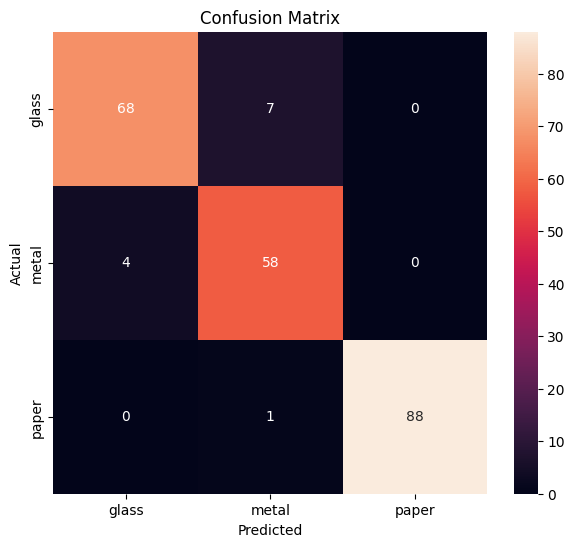

In [28]:
import seaborn as sns
from sklearn.metrics import  confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**20. Save final model**

In [29]:
import os

os.makedirs("/content/models", exist_ok=True)

model.save("/content/models/smart_waste_model.keras")

print("Model saved successfully!")
print(os.path.getsize("/content/models/smart_waste_model.keras") / (1024 * 1024), "MB")

Model saved successfully!
27.79213809967041 MB


In [30]:
model.save("/content/smart_waste_model.keras")

**Step 21: Download it to your PC**

In [31]:
from google.colab import files

files.download("/content/smart_waste_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>